In [1]:
import torch
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import random
from matplotlib.patches import Rectangle
import tifffile
import h5py
from torch.utils.data import DataLoader
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter

import importlib as imp
import sys
sys.path.append('/home/abenneck/Desktop/yolo_tiles/docs/scripts')

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec

## (1) Downsample each dataset along the 'slice' dimension

In [3]:
# curr_ax, idx_start = 0, 3600
# curr_ax, idx_start = 1, 8587
curr_ax, idx_start = 2, 7321

indir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}'
outdir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}_down'
conf_idx = 4
n_files = len(os.listdir(indir))

ds_count = 0
recon_down = []
time_start = time.time()

for idx, fname in enumerate(sorted(os.listdir(indir))):

    if idx < idx_start:
        continue
    
    # Increment count for current number of slices in the "to-be-downsampled" stack
    ds_count += 1

    # Load slice data
    data = np.load(os.path.join(indir, fname))

    # Append slice to the stack before downsampling
    recon_down.append(data)

    # Downsample every 8 slices
    if ds_count == 4:
        recon_down = np.stack(recon_down)
        inds = np.argmax(recon_down[..., conf_idx], axis = 0)
        recon_down_out = np.take_along_axis(recon_down, inds[None, :, :, None], axis=0)
        recon_down_out = recon_down_out[0]
        
        # Save downsampled output
        out_fname = fname[:30] + f'_ax{curr_ax}_{idx-3:05d}:{idx:05d}.npy'
        np.save(os.path.join(outdir, out_fname), recon_down_out)
        print(f'Downsampled slices {idx-3}-{idx}/{n_files} in {time.time()-time_start:.02f}s and saved outputs at {out_fname}')
        # break
        
        # Reset counts + empty the primary data structure
        time_start = time.time()
        recon_down = []
        ds_count = 0

Downsampled slices 6768-6771/7321 in 4.39s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06768:06771.npy
Downsampled slices 6772-6775/7321 in 4.06s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06772:06775.npy
Downsampled slices 6776-6779/7321 in 4.27s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06776:06779.npy
Downsampled slices 6780-6783/7321 in 4.02s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06780:06783.npy
Downsampled slices 6784-6787/7321 in 3.85s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06784:06787.npy
Downsampled slices 6788-6791/7321 in 4.04s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06788:06791.npy
Downsampled slices 6792-6795/7321 in 3.79s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06792:06795.npy
Downsampled slices 6796-6799/7321 in 4.13s and saved outputs at Ex_488_Em_525_stitched_full_sa_ax2_06796:06799.npy
Downsampled slices 6800-6803/7321 in 4.27s and saved outputs at Ex_488_Em_525_st

In [2]:
# Downsample 3D image along one axis. Useful for overlaying bbox outputs on MIPs
def vol_to_mip(vol, ax_idx, ds_factor = 8, slice_idx = -1):
    """
    Convert a 3D image volume (vol) into a stack of 2D MIPs along an axis (ax_idx). 
    This is useful for visualizing outputs from the YOLO_3D pipeline.

    Parameters:
    ===========
    vol : array of shape N x M x K
        The image volume to be 'downsampled'
    ax_idx : int
        The axis along which MIPs should be generated
    ds_factor : int
        The number of slices to use in each MIP
    slice_idx : int
        Default - -1; If -1, return the downsampled 3d volume of 2d slices along 'ax_idx'. 
        Else, Return the MIP of [slice_idx:slice_idx+ds_factor] along 'ax_idx'.
        
    Returns:
    ========
    vol_mip : array 
        A stack of MIPs along the 'ax_idx' axis
    """
    if slice_idx == -1:
        vol_mip = []
        vol_dim = vol.shape[ax_idx]
        for i in np.arange(int(vol_dim/ds_factor)):
            
            if ax_idx == 0:
                vol_slice_stack = vol[(i*ds_factor):((i+1)*ds_factor), :, :]
            elif ax_idx == 1:
                vol_slice_stack = vol[:, (i*ds_factor):((i+1)*ds_factor), :]
            elif ax_idx == 2:
                vol_slice_stack = vol[:, :, (i*ds_factor):((i+1)*ds_factor)]
            else:
                raise Exception(f'vol only has {len(vol.shape)} axes, but ax_idx = {ax_idx} was passed')
                
            vol_slice_max = np.max(vol_slice_stack, axis=ax_idx)
            vol_mip.append(vol_slice_max)
                
        vol_mip = np.stack(vol_mip, axis=ax_idx)
        return vol_mip
    else:
        if ax_idx == 0:
            vol_slice_stack = vol[(slice_idx):(slice_idx+ds_factor-1), :, :]
        elif ax_idx == 1:
            vol_slice_stack = vol[:, (slice_idx):(slice_idx+ds_factor-1), :]
        elif ax_idx == 2:
            vol_slice_stack = vol[:, :, (slice_idx):(slice_idx+ds_factor-1)]
        else:
            raise Exception(f'vol only has {len(vol.shape)} axes, but ax_idx = {ax_idx} was passed')
            
        vol_slice_max = np.max(vol_slice_stack, axis=ax_idx)
        return vol_slice_max

### Plot Results

Finished loading images
Finished loading outputs
Finished orig bboxes in 41.85s
Finished ds bboxes in 42.35s


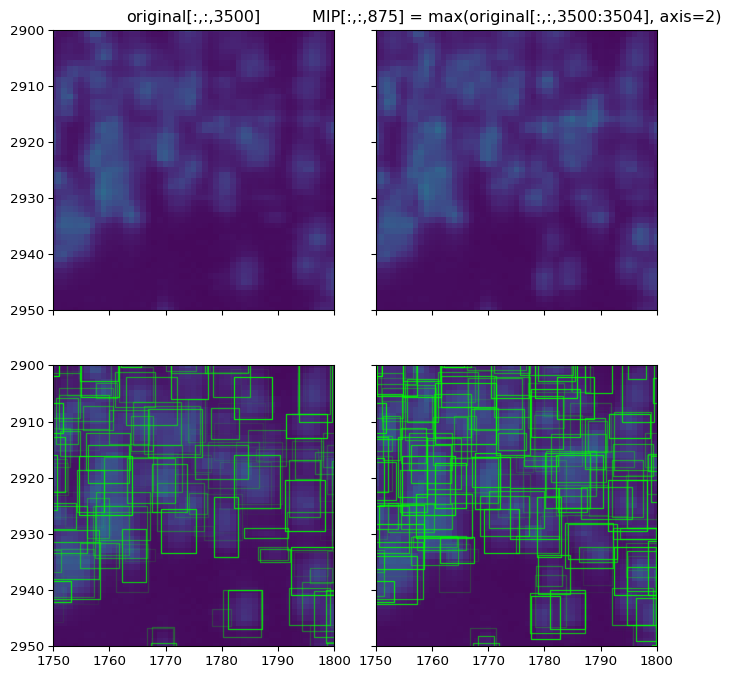

In [14]:
# Set parameters
ds_factor = 4
curr_ax = 2 # [0,1,2]
orig_slice_idx = 3500 # {0:[0,3600],1:[0,8587],2:[0,7321]}
out_slice_idx = int(orig_slice_idx/ds_factor)

# Load HDF5 3D input image
if curr_ax == 0:
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[orig_slice_idx, :, :]
    img_title = f'original[{orig_slice_idx},:,:]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[{out_slice_idx},:,:] = max(original[{orig_slice_idx}:{orig_slice_idx+4},:,:], axis={curr_ax})'
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_chunk32idx_{orig_slice_idx:05d}_:_:.npy'
elif curr_ax == 1:
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[:, orig_slice_idx, :]
    img_title = f'original[:,{orig_slice_idx},:]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[:,{out_slice_idx},:] = max(original[:,{orig_slice_idx}:{orig_slice_idx+4},:], axis={curr_ax})'
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_chunk32idx_:_{orig_slice_idx:05d}_:.npy'
else: # curr_ax = 2
    fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
    vol = h5py.File(fname)
    vol_stack = vol['stack']
    img = vol_stack[:, :, orig_slice_idx]
    img_title = f'original[:,:,{orig_slice_idx}]'
    img_mip = vol_to_mip(vol_stack, curr_ax, ds_factor = 4, slice_idx = orig_slice_idx)
    img_mip_title = f'MIP[:,:,{out_slice_idx}] = max(original[:,:,{orig_slice_idx}:{orig_slice_idx+4}], axis={curr_ax})'    
    slice_fname = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}/Ex_488_Em_525_stitched_full_sagidx_:_:_{orig_slice_idx:05d}.npy'
print('Finished loading images')    

# Load output files
recon_orig = np.load(slice_fname)
slice_fname_ds = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}_down/Ex_488_Em_525_stitched_full_sa_ax{curr_ax}_{orig_slice_idx:05d}:{orig_slice_idx+3:05d}.npy'
recon_ds = np.load(slice_fname_ds)
print('Finished loading outputs')    

# Generate visualization
fig, axs = plt.subplots(2, 2, layout='constrained', sharex=True, sharey=True)
axs[0,0].imshow(img)
axs[0,0].set_title(img_title)

time_start = time.time()
scores = recon_orig[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_orig, fc='none', ec='lime', alpha=scores)
axs[1,0].imshow(img)
axs[1,0].add_collection(predicted_rectangles)
print(f'Finished orig bboxes in {time.time()-time_start:.02f}s')

axs[0,1].imshow(img_mip)
axs[0,1].set_title(img_mip_title)

time_start = time.time()
scores = recon_ds[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(recon_ds, fc='none', ec='lime', alpha=scores)
axs[1,1].imshow(img_mip)
axs[1,1].add_collection(predicted_rectangles)
print(f'Finished ds bboxes in {time.time()-time_start:.02f}s')

for ax_i in axs:
    for ax in ax_i:
        # ax.set_xlim([4500,4750])
        # ax.set_ylim([1250,1000])
        # ax.set_xlim([5000,5250])
        # ax.set_ylim([1250,1000])
        ax.set_xlim([1750,1800])
        ax.set_ylim([2950,2900])

fig.set_size_inches(7,7)

## (2) Stitch together downsampled slices + save ijk cubes

In [2]:
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes'

indir0 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0_down'
data0 = np.load(os.path.join(indir0,os.listdir(indir0)[0]))
shape0 = data0.shape

indir1 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1_down'
data1 = np.load(os.path.join(indir1,os.listdir(indir1)[0]))
shape1 = data1.shape

indir2 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2_down'
data2 = np.load(os.path.join(indir2,os.listdir(indir2)[0]))
shape2 = data2.shape

out_dim = 256
final_shape = np.array([shape1[0], shape0[0], shape0[1]])
bbox_dim = 7 # Used to init 3D recon
num_classes = 3 # Used to init 3D recon

n_cube_i = final_shape[0] // out_dim # Num complete cubes along respective axis
n_cube_j = final_shape[1] // out_dim # Num complete cubes along respective axis
n_cube_k = final_shape[2] // out_dim # Num complete cubes along respective axis

next_i = 2
next_j = 5
next_k = 3

# Load 256 slices from each dir, stack them into 3 volumes, and combine the volumes into a 3D representation
for i in np.arange(n_cube_i + 1): # (+1) added to include edge case cubes
    
    if i < next_i:
        continue
        
    for j in np.arange(n_cube_j + 1):
        
        if j < next_j and i <= next_i:
            continue
            
        for k in np.arange(n_cube_k + 1):

            if k < next_k and i <= next_i and j <= next_j:
                continue

            # If cube lies on edge of volume, adjust relative idx accordingly
            edge_str = 'edge ' if i == n_cube_i or j == n_cube_j or k == n_cube_k else ''
            edge_i_end_idx = final_shape[0] if i == n_cube_i else (i+1)*(out_dim)
            edge_j_end_idx = final_shape[1] if j == n_cube_j else (j+1)*(out_dim)
            edge_k_end_idx = final_shape[2] - 2 if k == n_cube_k else (k+1)*(out_dim)
            # print(f'End idx: ({edge_i_end_idx}, {edge_j_end_idx}, {edge_k_end_idx})')
            
            print(f'Starting {edge_str}cube ({i},{j},{k}) . . .')
            time_total = time.time()
            
            # Load and stack outputs from ax0 slices
            time_start = time.time()
            out_stack0 = []
            count0 = 0
            idx_start0 = i*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir0))):
                if idx < idx_start0:
                    continue
                out_slice = np.memmap(os.path.join(indir0,fname), dtype=np.float32, shape = shape0)

                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(j*out_dim):edge_j_end_idx,(k*out_dim):edge_k_end_idx,:]
                out_stack0.append(out_slice)
            
                count0 += 1
                if count0 == out_dim:
                    count0 = 0
                    break
            out_stack0 = np.stack(out_stack0, axis = 0)
            print(f'Finished ax0 in {time.time()-time_start:.2f}s with shape {out_stack0.shape}')

            # Load and stack outputs from ax1 slices
            time_start = time.time()
            out_stack1 = []
            count1 = 0
            idx_start1 = j*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir1))):
                if idx < idx_start1:
                    continue
                out_slice = np.memmap(os.path.join(indir1,fname), dtype=np.float32, shape = shape1)
                
                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(i*out_dim):edge_i_end_idx,(k*out_dim):edge_k_end_idx,:]
                out_stack1.append(out_slice)
            
                count1 += 1
                if count1 == out_dim:
                    count1 = 0
                    break
            out_stack1 = np.stack(out_stack1, axis = 0).transpose(1,0,2,3)
            print(f'Finished ax1 in {time.time()-time_start:.2f}s with shape {out_stack1.shape}')

            # Load and stack outputs from ax2 slices
            time_start = time.time()
            out_stack2 = []
            count2 = 0
            idx_start2 = k*out_dim
            for idx, fname in enumerate(sorted(os.listdir(indir2))):
                if idx < idx_start2:
                    continue
                out_slice = np.memmap(os.path.join(indir2,fname), dtype=np.float32, shape = shape2)
                
                # TODO: Extract relevant 256x256 image from whole image before adding image to the stack
                out_slice = out_slice[(i*out_dim):edge_i_end_idx,(j*out_dim):edge_j_end_idx,:]
                out_stack2.append(out_slice)
            
                count2 += 1
                if count2 == out_dim:
                    count2 = 0
                    break
            out_stack2 = np.stack(out_stack2, axis = 0).transpose(1,2,0,3)
            print(f'Finished ax2 in {time.time()-time_start:.2f}s with shape {out_stack2.shape}')

            # Combine the 3 volumes into 1 volume where each elem is a bounding cube
            i_lim = final_shape[0] % out_dim - 1 if i == n_cube_i else out_dim
            j_lim = final_shape[1] % out_dim - 3 if j == n_cube_j else out_dim
            k_lim = final_shape[2] % out_dim - 2 if k == n_cube_k else out_dim
            # print(i_lim, j_lim, k_lim)
            recon_total = np.ones((out_dim, out_dim, out_dim, bbox_dim+num_classes))*(-np.inf)
            for i_ in np.arange(i_lim):
                for j_ in np.arange(j_lim):
                    for k_ in np.arange(k_lim):

                        xmin = (out_stack2[i_,j_,k_,1] + out_stack1[i_,j_,k_,1]) / 2
                        xmax = (out_stack2[i_,j_,k_,3] + out_stack1[i_,j_,k_,3]) / 2
                        ymin = (out_stack2[i_,j_,k_,0] + out_stack0[i_,j_,k_,1]) / 2
                        ymax = (out_stack2[i_,j_,k_,2] + out_stack0[i_,j_,k_,3]) / 2
                        zmin = (out_stack1[i_,j_,k_,0] + out_stack0[i_,j_,k_,0]) / 2
                        zmax = (out_stack1[i_,j_,k_,2] + out_stack0[i_,j_,k_,2]) / 2
                        
                        conf = np.min([out_stack0[i_,j_,k_,4], out_stack1[i_,j_,k_,4], out_stack2[i_,j_,k_,4]])
                        
                        cl0 = np.mean([out_stack0[i_,j_,k_,5], out_stack1[i_,j_,k_,5], out_stack2[i_,j_,k_,5]])
                        cl1 = np.mean([out_stack0[i_,j_,k_,6], out_stack1[i_,j_,k_,6], out_stack2[i_,j_,k_,6]])
                        cl2 = np.mean([out_stack0[i_,j_,k_,7], out_stack1[i_,j_,k_,7], out_stack2[i_,j_,k_,7]])
                        
                        recon_total[i_,j_,k_] = [xmin, xmax, ymin, ymax, zmin, zmax, conf, cl0, cl1, cl2]
            
            # Save output cube using ijk format in fname
            out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_d{out_dim}_Ex_488_Em_525.npy'
            # out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_di{ilim}_dj{j_lim}_dk{k_lim}_Ex_488_Em_525.npy'
            np.save(os.path.join(outdir, out_fname), recon_total)
            print(f'Saved cube ({i},{j},{k}) in {time.time()-time_total:.2f}s as {out_fname} in {outdir}\n')

            # break
        # break
    # break


Starting cube (2,5,3) . . .
Finished ax0 in 0.55s with shape (256, 256, 256, 8)
Finished ax1 in 0.51s with shape (256, 256, 256, 8)
Finished ax2 in 0.52s with shape (256, 256, 256, 8)
Saved cube (2,5,3) in 701.33s as i0002_j0005_k0003_d256_Ex_488_Em_525.npy in /nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes

Starting cube (2,5,4) . . .
Finished ax0 in 0.50s with shape (256, 256, 256, 8)
Finished ax1 in 0.47s with shape (256, 256, 256, 8)
Finished ax2 in 0.53s with shape (256, 256, 256, 8)
Saved cube (2,5,4) in 702.38s as i0002_j0005_k0004_d256_Ex_488_Em_525.npy in /nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes

Starting cube (2,5,5) . . .
Finished ax0 in 0.43s with shape (256, 256, 256, 8)
Finished ax1 in 0.42s with shape (256, 256, 256, 8)
Finished ax2 in 0.52s with shape (256, 256, 256, 8)
Saved cube (2,5,5) in 702.56s as i0002_j0005_k0005_d256_Ex_488_Em_525.npy in /nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes

Star

### Plot results

Finished loading bbox data in 0.32s
Finished loading images in 109.49s
Plotting bboxes . . .
Finished plotting everything in 5.37s


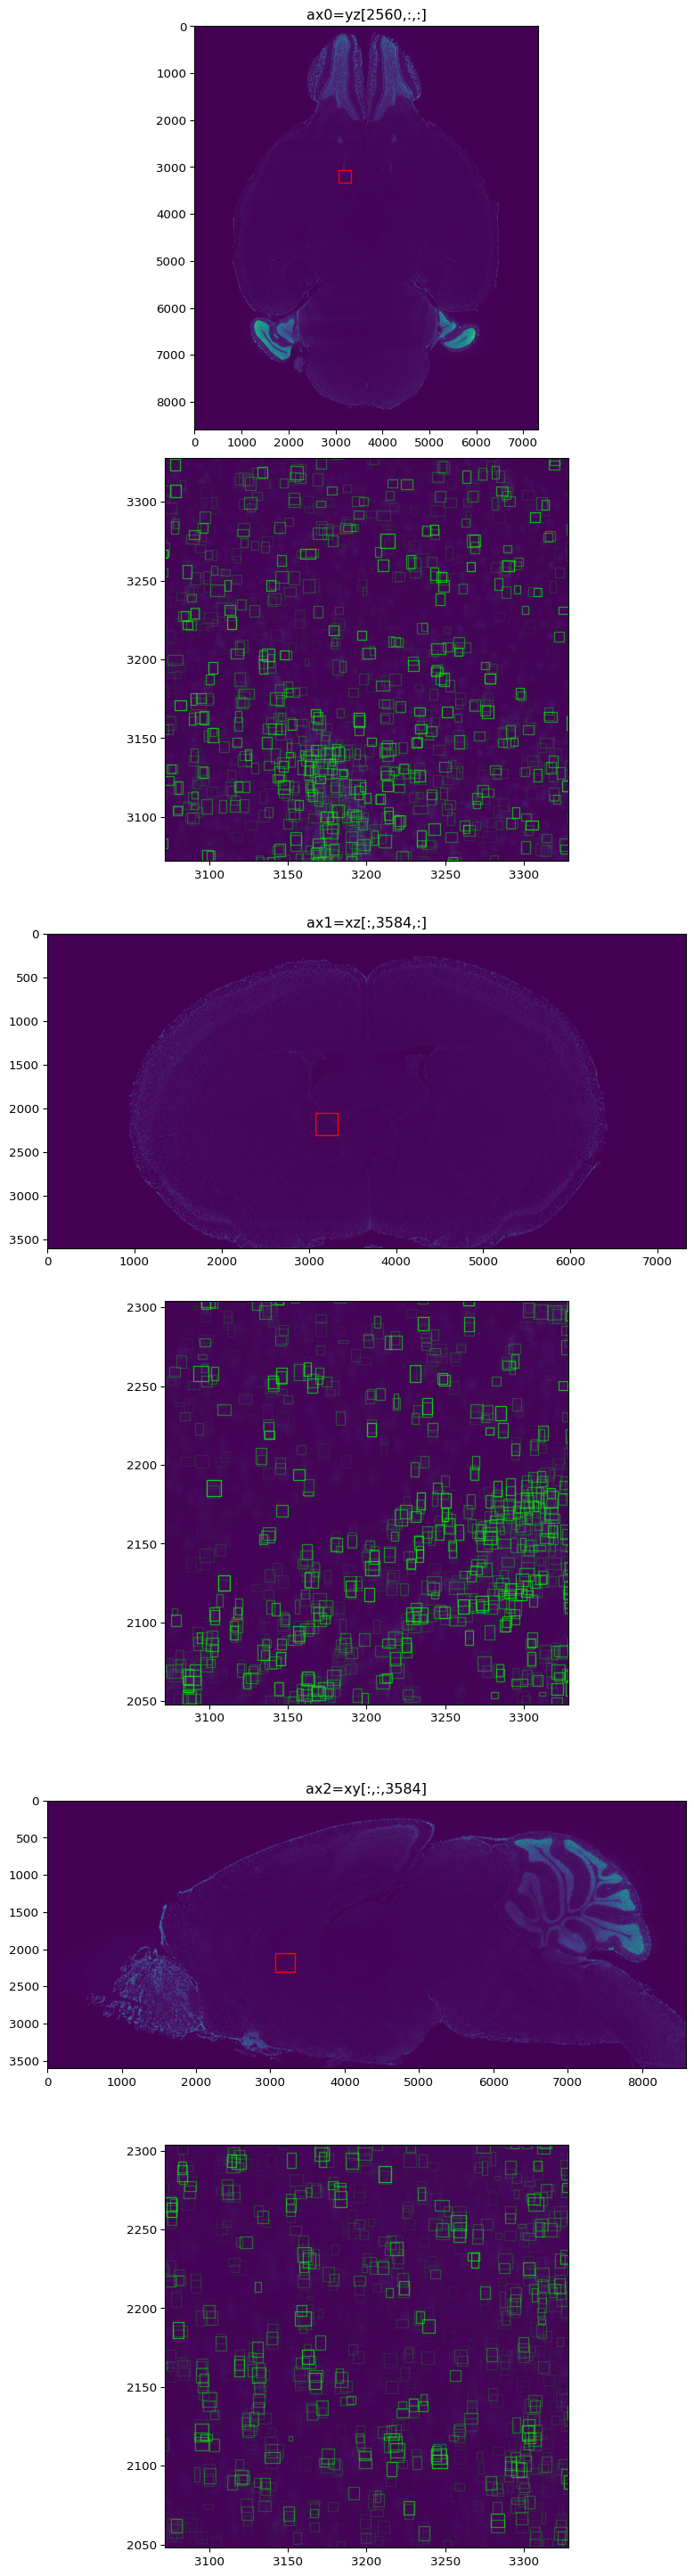

In [11]:
# Set key parameters
ds_factor = 4
out_dim = 256
orig_slice_dim = out_dim * ds_factor
mid_slice_dim = int(orig_slice_dim / 2)
shift = 768

# Load output data cube + extract data from relevant slices
time_start = time.time()
outdir = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/cubes'
i, j, k = 2, 3, 3
out_fname = f'i{i:04d}_j{j:04d}_k{k:04d}_d{out_dim}_Ex_488_Em_525.npy'
data = np.load(os.path.join(outdir, out_fname))

orig_slice_idx0 = (i*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax0
down_slice_idx0 = int((orig_slice_idx0 % 1024) / ds_factor)
data0 = data[down_slice_idx0,:,:,:]

orig_slice_idx1 = (j*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax1
down_slice_idx1 = int((orig_slice_idx1 % 1024) / ds_factor)
data1 = data[:,down_slice_idx1,:,:]

orig_slice_idx2 = (k*1024)+512 # Idx of the first img slice in the stack to be downsampled, from the middle of ax2
down_slice_idx2 = int((orig_slice_idx2 % 1024) / ds_factor)
data2 = data[:,:,down_slice_idx2,:]
print(f'Finished loading bbox data in {time.time()-time_start:.2f}s')

# Load original HDF5 3D images + convert to MIPs for visualization
time_start = time.time()
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip0 = vol_to_mip(vol_stack, 0, ds_factor = 4, slice_idx = orig_slice_idx0)

fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip1 = vol_to_mip(vol_stack, 1, ds_factor = 4, slice_idx = orig_slice_idx1)

fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_full_sag.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img_mip2 = vol_to_mip(vol_stack, 2, ds_factor = 4, slice_idx = orig_slice_idx2)
print(f'Finished loading images in {time.time()-time_start:.2f}s')

# Initialize output figure
time_start = time.time()
nrow, ncol = 6,1
fig, axs = plt.subplots(nrow, ncol, layout='constrained')
axs[0].imshow(img_mip0)
axs[0].add_patch(Rectangle((orig_slice_idx1-512,orig_slice_idx2-512),1024-shift,1024-shift,fc='none',ec='r'))
axs[0].set_title(f'ax0=yz[{orig_slice_idx0},:,:]')
axs[2].imshow(img_mip1)
axs[2].set_title(f'ax1=xz[:,{orig_slice_idx1},:]')
axs[2].add_patch(Rectangle((orig_slice_idx2-512,orig_slice_idx0-512),1024-shift,1024-shift,fc='none',ec='r'))
axs[4].imshow(img_mip2)
axs[4].set_title(f'ax2=xy[:,:,{orig_slice_idx2}]')
axs[4].add_patch(Rectangle((orig_slice_idx1-512,orig_slice_idx0-512),1024-shift,1024-shift,fc='none',ec='r'))

print('Plotting bboxes . . .')

scores = data0[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data0, pos = [4,2,5,3], fc='none', ec='lime', alpha=scores)
axs[1].imshow(img_mip0)
axs[1].add_collection(predicted_rectangles)
axs[1].set_xlim([orig_slice_idx1-512, orig_slice_idx1+512-shift])
axs[1].set_ylim([orig_slice_idx2-512, orig_slice_idx2+512-shift])

scores = data1[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data1, pos = [4,0,5,1], fc='none', ec='lime', alpha=scores)
axs[3].imshow(img_mip1)
axs[3].add_collection(predicted_rectangles)
axs[3].set_xlim([orig_slice_idx2-512, orig_slice_idx2+512-shift])
axs[3].set_ylim([orig_slice_idx0-512, orig_slice_idx0+512-shift])

scores = data2[:,:,-4].ravel()
predicted_rectangles = bb_to_rec(data2, pos = [2,0,3,1], fc='none', ec='lime', alpha=scores)
axs[5].imshow(img_mip2)
axs[5].add_collection(predicted_rectangles)
axs[5].set_xlim([orig_slice_idx1-512, orig_slice_idx1+512-shift])
axs[5].set_ylim([orig_slice_idx0-512, orig_slice_idx0+512-shift])

fig.set_size_inches(ncol*8, nrow*5)
# plt.savefig(os.path.join(outdir, f'recon_slice_{slice_idx:03d}.png'))
print(f'Finished plotting everything in {time.time()-time_start:.2f}s')


In [10]:
fig.savefig(os.path.join('/home/abenneck/Desktop/yolo3d_outputs/','slices_cube_i2_j3_k3_refined2.jpg'))

In [31]:
indir0 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax0_down'
data0 = np.load(os.path.join(indir0,os.listdir(indir0)[0]))
shape0 = data0.shape

indir1 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax1_down'
data1 = np.load(os.path.join(indir1,os.listdir(indir1)[0]))
shape1 = data1.shape

indir2 = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax2_down'
data2 = np.load(os.path.join(indir2,os.listdir(indir2)[0]))
shape2 = data2.shape

out_dim = 256
final_shape = np.array([shape1[0], shape0[0], shape0[1]])

final_shape / out_dim

array([3.515625, 8.390625, 7.15625 ])

In [ ]:
recon_down_out = np.load(os.path.join(outdir, out_fname))

for i in np.arange(recon_down.shape[1]):
    for j in np.arange(recon_down.shape[2]):
        if i == j:
            print(f'{i:05d},{j:05d}')
            print(f'{recon_down[:,i,j,:]}')
            print(f'{recon_down_out[i,j,:]}\n')

In [52]:
# Loop to add leading 0s to the fnames of all slices along ax = curr_ax
if False:
    for fname in sorted(os.listdir(indir)):
    
        if curr_ax == 0:
            idx = int(fname.split('_')[-3])
            new_fname = fname[:34] + f'{idx:05d}_:_:.npy'
        elif curr_ax == 1:
            idx = int(fname.split('_')[-2])
            new_fname = fname[:34] + f':_{idx:05d}_:.npy'
        else: # curr_ax == 2
            idx = int(fname.split('_')[-1][:-4])
            new_fname = fname[:35] + f':_:_{idx:05d}.npy'
    
        print(f'{fname} => {new_fname}')
    
        if fname != new_fname:   
            os.system(f'mv {os.path.join(indir,fname)} {os.path.join(indir,new_fname)}')

'Ex_488_Em_525_stitched_chunk32idx_00836_:_:.npy'